## Example of the `aitlas` toolbox in the context of image segmentation
---
```
Author: Ana Kostovska
Organisation: Bias Variance Labs
Website: https://www.bvlabs.ai/
Ljubljana, 2024
```
---

### Importing required packages

In [1]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
# from aitlas.datasets import TiiLIDARDatasetSegmentation
import torch
from aitlas.models import HRNet

In [36]:
# Dataset class

import os
import glob
import numpy as np
import rasterio
import imageio
import torch
from collections import defaultdict

from aitlas.utils import image_loader
from aitlas.datasets.semantic_segmentation import SemanticSegmentationDataset
from aitlas.datasets.schemas import TiiLIDARDatasetBinaryWithPreprocessingSchema

'''
    The format of rasters:
    Band 0 - barrow
    Band 1 - enclosure
    Band 2 - ringfort
    shape = [band, height, width]

    Each band is coded with the following pixel values:
    0 - background
    1 - DFM = 1
    2 - DFM = 2
    3 - DFM = 3
    4 - DFM = 4
    5 - new object (Archaeological False Positive from the ML results analysis)
'''

class StoneDatasetSegmentation(SemanticSegmentationDataset):
    schema = TiiLIDARDatasetBinaryWithPreprocessingSchema
    url = ""

    labels = ["Background","Archaeology"]
    color_mapping = [[0,0,0],[255, 255, 255]]
    name = "Stone ALS barrows"

    @staticmethod
    def get_fixed_model_config():
        """
        These model parameters are fixed and saved here for simple use.
        It is a config dictionary, user can acces it by calling this method on the class.
        """
        return {
            "num_classes": 2,
            "learning_rate": 0.0001,
            "pretrained": True,
            "use_cuda": torch.cuda.is_available(),
            "threshold": 0.5,
            "metrics": ["iou"]
        }

    def __init__(self, config):
        # now call the constructor to validate the schema and split the data
        super().__init__(config)
        self.images = []
        self.masks = []
        self.load_dataset(self.config.data_dir)

    # ---------- data access ----------
    def __getitem__(self, index):
        """
        Read image and transpose into the correct shape
        (C,H,W) -> (H,W,C)
        """
        # Open the selected image
        with rasterio.open(self.images[index]) as image_tiff:
            image = image_tiff.read()
        # Make sure it has 3 bands!
        if image.shape[0] == 1:
            image = np.repeat(image, 3, axis=0)
        # (C,H,W) -> (H,W,C)
        image = np.transpose(image, (1, 2, 0))

        # Read/construct mask (binary 0/1), (H, W) uint8
        mask = self.process_single_mask(self.masks[index])
        
        # TODO: Check what this does, I'm not sure it is needed
        masks = [(mask == v) for v, label in enumerate(self.labels)]
        mask = np.stack(masks, axis=-1).astype("float32")
        
        return self.apply_transformations(image, mask)

    
    # ---------- mask reading (AO-aware) ----------
    def process_single_mask(self, mask_path):
        """
        mask_path: str
        DFM_setting: dict  # i.e. self.DFM_quality
        object_class: str
        object_class_band_id: int
        """
        with rasterio.open(mask_path) as src:
            if self.object_class == "AO":
                # Read all 3 bands
                arr = src.read()  # (B, H, W)
                # Keep only selected DFM quality and collapse 3 bands to 1 (boolean)
                mask_bool = np.isin(arr, self.DFM_quality).any(axis=0)  # (H, W) bool
            else:
                # Read specific band
                band = src.read(self.object_class_band_id + 1)  # (H, W)
                # Keep only selected DFM quality
                mask_bool = np.isin(band, self.DFM_quality)  # (H, W) bool
            
        return mask_bool.astype(np.uint8)  # {0,1}


    # ---------- Helper for load_dataset, cheks if mask is empty ----------
    def should_include_mask(self, mask_path, DFM_setting, keep_empty_patches, object_class, object_class_band_id):
        """
        Checks if mask is empty
        
        - Because masks have 3 bands, if training for only 1 class, some images will have empty masks (for example, image has
        only barrows, so if trainning for ringforts, this image will have an empty mask for ringfort).
        - It can also happen if we have images with only background. It is set to False when training since "empty" data can't 
        be used for training. For testing or validation, True can be used to check how the model handles empty patches.
        """
        if(keep_empty_patches):
            return True
        else:
            mask = imageio.imread(mask_path)
            # Check if transpose is necessary
            if mask.ndim == 3 and mask.shape[0] == 3:
                mask = np.transpose(mask, (1, 2, 0))
            
            mask = np.isin(mask, DFM_setting).astype(np.uint8)
            
            if (object_class!='AO'):
                mask = mask[:,:,object_class_band_id] # filter object_class
            else: 
                mask = np.squeeze(np.max(mask, axis=2, keepdims=True))
            
            return not np.all(mask == 0)

        
        
    def load_dataset(self, data_dir):
        """
        Build the dataset by pairing masks with images using the first two '__' parts.
        Assumes every mask is valid (contains at least one positive), so we SKIP
        per-mask filtering for speed/simplicity.
        """
        # Cache config
        self.object_class = self.config.object_class  # e.g., 'barrow' or 'AO'
        self.object_class_band_id = self.config.object_class_band_id  # 0/1/2 for single-class
        self.DFM_quality = [int(item) for item in self.config.DFM_quality.split(',')]  # e.g., "1" -> [1]
        self.keep_empty_patches = self.config.keep_empty_patches
        annotations_dir = self.config.annotations_dir

        # # Build image index once
        # image_index = self._build_image_index(
        #     images_dir=data_dir,
        #     prefer_visualisation=getattr(self.config, "visualisation_type", None),
        # )

        # self.images.clear()
        # self.masks.clear()

        # for mask_filename in os.listdir(annotations_dir):
        #     if not mask_filename.lower().endswith((".tif", ".tiff")):
        #         continue

        #     key = self._two_part_prefix(mask_filename)
        #     if not key:
        #         # Skip masks that don't follow 'A__B__...' naming
        #         continue

        #     image_path = image_index.get(key)
        #     if not image_path:
        #         # No matching image for this key
        #         continue

        #     mask_path = os.path.join(annotations_dir, mask_filename)

        #     #TODO: Also add check for empty masks, at the moment it is removed (i.e. should_include_mask())

        #     # Since preprocessing guarantees positives, just append
        #     self.images.append(image_path)
        #     self.masks.append(mask_path)

        # if not self.images:
        #     raise RuntimeError(
        #         "No image/mask pairs loaded. Check directory paths and filename prefixes."
        #     )

        
        for mask_filename in os.listdir(annotations_dir):
            if (mask_filename.endswith(".tif")):
                image_path = f'{data_dir}/{mask_filename.split("__")[0]}__{mask_filename.split("__")[1]}__{self.config.visualisation_type}.tif'
                if (os.path.isfile(image_path) and 
                    os.path.isfile(os.path.join(annotations_dir, mask_filename)) and 
                    self.should_include_mask(os.path.join(annotations_dir, mask_filename), self.DFM_quality, self.keep_empty_patches, self.object_class, self.object_class_band_id)) :
                    mask_path = os.path.join(annotations_dir, mask_filename)
                    self.masks.append(mask_path)
                    self.images.append(image_path)

    
    # ---------- helpers: matching by two-part prefix ----------

    @staticmethod
    def _two_part_prefix(filename: str) -> str:
        """
        Extract the match key as the first two '__'-separated parts.
        Example: 'A__B__anything_else.tif' -> 'A__B'
        """
        parts = filename.split("__")
        return f"{parts[0]}__{parts[1]}" if len(parts) >= 2 else ""

    @staticmethod
    def _build_image_index(images_dir, prefer_visualisation):
        """
        Scan the images directory once and build an index:
            key = first two '__' parts (e.g., 'A__B')
            value = best-matching image path for that key
        If multiple images share a key, prefer those whose filename contains
        the requested visualisation token (e.g., 'slrm'); else pick a stable default.
        """
        idx = defaultdict(list)

        # Collect candidate image files (.tif/.tiff, any case)
        for ext in ("*.tif", "*.tiff", "*.TIF", "*.TIFF"):
            for p in glob.glob(os.path.join(images_dir, ext)):
                key = StoneDatasetSegmentation._two_part_prefix(os.path.basename(p))
                if key:
                    idx[key].append(p)

        # Choose the "best" path per key
        best = {}
        pref = (prefer_visualisation or "").lower()
        for key, paths in idx.items():
            if pref:
                cand = [p for p in paths if pref in os.path.basename(p).lower()]
                if cand:
                    best[key] = sorted(cand)[0]
                    continue
            # Fallback: deterministic choice: shortest filename, then lexicographic
            best[key] = sorted(
                paths,
                key=lambda p: (len(os.path.basename(p)), os.path.basename(p).lower())
            )[0]
        return best


In [3]:
import os
import numpy as np
import rasterio
import imageio
import torch

from aitlas.utils import image_loader
from aitlas.datasets.semantic_segmentation import SemanticSegmentationDataset
from aitlas.datasets.schemas import TiiLIDARDatasetBinaryWithPreprocessingSchema
'''
    The new format of the file is as follows:
    Band 0 - barrow
    Band 1 - enclosure
    Band 2 - ringfort

    Each band is coded with the following values:
    0 - background
    1 - DFM = 1
    2 - DFM = 2
    3 - DFM = 3
    4 - DFM = 4
    5 - new object (Archaeological False Positive from the ML results analysis)
'''

class TiiLIDARDatasetSegmentation(SemanticSegmentationDataset):
    schema = TiiLIDARDatasetBinaryWithPreprocessingSchema
    url = ""

    labels = ["Background","AO"]
    color_mapping = [[0,0,0],[255, 255, 255]]
    name = "TII LIDAR Binary"

    def get_fixed_model_config():
        return {
            "num_classes": 2,
            "learning_rate": 0.0001,
            "pretrained": True,
            "use_cuda": torch.cuda.is_available(),
            "threshold": 0.5,
            "metrics": ["iou"]
    }
    
    def __init__(self, config):
        # now call the constructor to validate the schema and split the data
        super().__init__(config)
        self.images = []
        self.masks = []
        self.load_dataset(self.config.data_dir)

    def __getitem__(self, index):
        with rasterio.open(self.images[index]) as image_tiff:
            image = image_tiff.read()
        if image.shape[0] == 1:
            image = np.repeat(image, 3, axis=0)
        image = np.transpose(image, (1, 2, 0))
        mask = self.process_single_mask(self.masks[index], self.DFM_quality, self.object_class, self.object_class_band_id)
        masks = [(mask == v) for v, label in enumerate(self.labels)]
        mask = np.stack(masks, axis=-1).astype("float32")
        return self.apply_transformations(image, mask)
    
    def should_include_mask(self, mask_path, DFM_setting, keep_empty_patches, object_class, object_class_band_id):
        if(keep_empty_patches):
            return True
        else:
            mask = imageio.imread(mask_path)
            # Check if transpose is necessary
            if mask.ndim == 3 and mask.shape[0] == 3:
                mask = np.transpose(mask, (1, 2, 0))
            mask = np.isin(mask, DFM_setting).astype(np.uint8)
            if (object_class!='AO'):
                mask = mask[:,:,object_class_band_id] # filter object_class
            else: 
                mask = np.squeeze(np.max(mask, axis=2, keepdims=True))
            return not np.all(mask == 0)
        
    
    def process_single_mask(self, mask_path, DFM_setting, object_class, object_class_band_id):
        mask = imageio.imread(mask_path)
        # Check if transpose is necessary
        if mask.ndim == 3 and mask.shape[0] == 3:
            mask = np.transpose(mask, (1, 2, 0))
        mask = np.isin(mask, DFM_setting).astype(np.uint8)
        if (object_class!='AO'):
            mask = mask[:,:,object_class_band_id] # filter object_class
        else:
            mask = np.squeeze(np.max(mask, axis=2, keepdims=True))
        return mask
        
    def load_dataset(self, data_dir):
        self.object_class = self.config.object_class
        self.object_class_band_id = self.config.object_class_band_id
        self.DFM_quality = [int(item) for item in self.config.DFM_quality.split(',')]
        self.keep_empty_patches = self.config.keep_empty_patches
        annotations_dir = self.config.annotations_dir
        for mask_filename in os.listdir(annotations_dir):
            if (mask_filename.endswith(".tif")):
                image_path = f'{data_dir}/{mask_filename.split("__")[0]}__{mask_filename.split("__")[1]}__{self.config.visualisation_type}.tif'
                if (os.path.isfile(image_path) and 
                    os.path.isfile(os.path.join(annotations_dir, mask_filename)) and 
                    self.should_include_mask(os.path.join(annotations_dir, mask_filename), self.DFM_quality, self.keep_empty_patches, self.object_class, self.object_class_band_id)) :
                    mask_path = os.path.join(annotations_dir, mask_filename)
                    self.masks.append(mask_path)
                    self.images.append(image_path)




In [48]:
from aitlas.datasets import TiiLIDARDatasetSegmentation

In [2]:
from stone_dataset import StoneDatasetSegmentation

In [16]:
from aitlas.datasets import TiiLIDARDatasetSegmentation

### Loading train, validation and test data

Input parameters for train, validation and test data:

- **batch_size**: The number of samples processed before the model is updated. A larger batch size can speed up processing but requires more memory.
- **num_workers**: The number of worker processes that will be used for processing data. Increasing the number of workers can significantly speed up data processing, however, it also increases memory and CPU/GPU usage.
- **object_class**: A parameter that specifies the type of archaeological object you are interested in processing, e.g., 'AO', 'barrow', 'enclosure', 'ringfort'.
- **object_class_band_id**: An integer parameter identifying the band where the annotations for a specific object class are located within the segmentation masks.
- **visualisation_type**: The vizuelization type used for the patches, e.g., 'SLRM'.
- **DFM_quality**: List of annotation qualities to be included in the processed data, e.g., '1,2'.
- **keep_empty_patches**: A boolean parameter that controls if empty patches are kept. Set to False when training since "empty" data can't be used for training. For testing or validation, True can be used to check how the model handles empty patches.
- **shuffle**: Determines whether the data should be shuffled before being processed. 
- **data_dir**: The directory path where the input data is stored. 
- **annotations_dir**: The directory path where the segmentation masks are stored. 
- **transforms**: A list of transformations applied to the input data during processing.
- **target_transforms**: A list of transformations applied to the segmentation masks during processing.
- **joint_transforms**: Transformations applied simultaneously to both the input data and segmentation masks.

In [46]:
batch_size = 16
num_workers = 2
object_class = "barrow"
object_class_band_id = 0   # 0, 1, 2 for bands in GeoTIFF
visualisation_type = "SLRM"

In [4]:
# Stone DATA
train_data = r"r:\delovno\nejc\training_samples_BiH_v3\train\images"
train_mask = r"r:\delovno\nejc\training_samples_BiH_v3\train\segmentation_masks"

validation_data = r"r:\delovno\nejc\training_samples_BiH_v3\validation\images"
validation_mask = r"r:\delovno\nejc\training_samples_BiH_v3\validation\segmentation_masks"

test_data = r"r:\delovno\nejc\training_samples_BiH_v3\test\images"
test_mask = r"r:\delovno\nejc\training_samples_BiH_v3\test\segmentation_masks"

In [ ]:
# Test data from ADAF dataset
train_data = r"r:\delovno\nejc\test_adaf_retrain\samples\train"
train_mask = r"r:\delovno\nejc\test_adaf_retrain\labels\segmentation_masks\train"

validation_data = r"r:\delovno\nejc\test_adaf_retrain\samples\validation"
validation_mask = r"r:\delovno\nejc\test_adaf_retrain\labels\segmentation_masks\validation"

test_data = r"r:\delovno\nejc\test_adaf_retrain\samples\test"
test_mask = r"r:\delovno\nejc\test_adaf_retrain\labels\segmentation_masks\test"

In [21]:
# Test data from ADAF dataset
train_data2 = r"r:\delovno\nejc\test_adaf_retrain\samples\train"
train_mask2 = r"r:\delovno\nejc\test_adaf_retrain\labels\segmentation_masks\train"

train_dataset_config2 = {
    "batch_size": batch_size,
    "num_workers": num_workers,
    "object_class": object_class,
    "object_class_band_id": object_class_band_id,
    "visualisation_type": visualisation_type,
    "DFM_quality": '1',
    "shuffle": True,
    "keep_empty_patches": False,
    "data_dir": train_data2,
    "annotations_dir": train_mask2,
    "joint_transforms": ["aitlas.transforms.FlipHVRandomRotate"],
    "transforms": ["aitlas.transforms.Transpose"],
	"target_transforms": ["aitlas.transforms.Transpose"]
}
train_dataset2 = TiiLIDARDatasetSegmentation(train_dataset_config2)

train_dataset2.__getitem__(0)[1].size()

torch.Size([2, 512, 512])

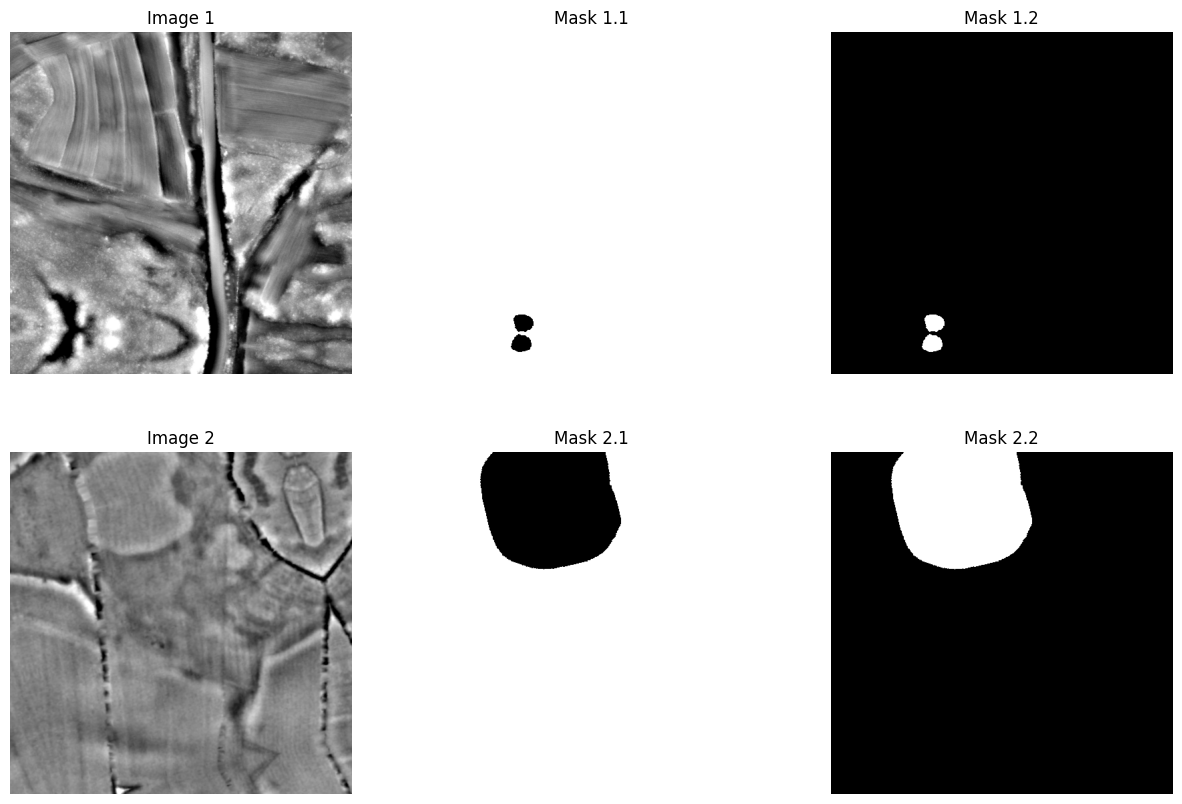

In [58]:
import matplotlib.pyplot as plt
adaf_tensor = train_dataset2.__getitem__(10)
stone_tensor = train_dataset.__getitem__(10)

plt.figure(figsize=(15, 10))

# --- Row 1 ---
plt.subplot(2, 3, 1)
plt.imshow(stone_tensor[0].permute(1, 2, 0).detach().cpu().numpy())
plt.title("Image 1")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(stone_tensor[1][0].cpu().numpy(), cmap='gray')
plt.title("Mask 1.1")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(stone_tensor[1][1].cpu().numpy(), cmap='gray')
plt.title("Mask 1.2")
plt.axis("off")

# --- Row 2 ---
plt.subplot(2, 3, 4)
plt.imshow(adaf_tensor[0].permute(1, 2, 0).detach().cpu().numpy())
plt.title("Image 2")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(adaf_tensor[1][0].cpu().numpy(), cmap='gray')
plt.title("Mask 2.1")
plt.axis("off")

plt.subplot(2, 3, 6)
plt.imshow(adaf_tensor[1][1].cpu().numpy(), cmap='gray')
plt.title("Mask 2.2")
plt.axis("off")

plt.show()

In [40]:
train_dataset.masks[10]

'r:\\delovno\\nejc\\training_samples_BiH_v3\\train\\segmentation_masks\\265216_4802816__BiH_ALS_2025_DMO_05m_slrm__segmentation_masks.tif'

In [42]:
import rasterio
src = rasterio.open(train_dataset.masks[10])

In [52]:
band = src.read(3)
band.sum()

0

In [55]:
train_dataset_config = {
    "batch_size": batch_size,
    "num_workers": num_workers,
    "object_class": object_class,
    "object_class_band_id": object_class_band_id,
    "visualisation_type": visualisation_type,
    "DFM_quality": '1',
    "shuffle": True,
    "keep_empty_patches": False,
    "data_dir": train_data,
    "annotations_dir": train_mask,
    "joint_transforms": ["aitlas.transforms.FlipHVRandomRotate"],
    "transforms": ["aitlas.transforms.Transpose"],
	"target_transforms": ["aitlas.transforms.Transpose"]
}
train_dataset = StoneDatasetSegmentation(train_dataset_config)

validation_dataset_config = {
    "batch_size": batch_size,
    "num_workers": num_workers,
    "object_class": object_class,
    "object_class_band_id": object_class_band_id,
    "visualisation_type": visualisation_type,
    "DFM_quality": '1',
    "shuffle": False,
    "keep_empty_patches": False,
    "data_dir": validation_data,
    "annotations_dir": validation_mask,
    "transforms": ["aitlas.transforms.Transpose"],
    "target_transforms": ["aitlas.transforms.Transpose"]
}
validation_dataset = StoneDatasetSegmentation(validation_dataset_config)

test_dataset_config = {
    "batch_size": batch_size,
    "num_workers": num_workers,
    "object_class": object_class,
    "object_class_band_id": object_class_band_id,
    "visualisation_type": visualisation_type,
    "DFM_quality": '1',
    "shuffle": False,
    "keep_empty_patches": False,
    "data_dir": test_data,
    "annotations_dir": test_mask,
    "transforms": ["aitlas.transforms.Transpose"],
	"target_transforms": ["aitlas.transforms.Transpose"]
}
test_dataset = StoneDatasetSegmentation(test_dataset_config)

len(train_dataset), len(validation_dataset), len(test_dataset)

(4383, 708, 931)

In [11]:
train_dataset.images[99]

'r:\\delovno\\nejc\\training_samples_BiH_v3\\train\\images\\267264_4757248__BiH_ALS_2025_DMO_05m_slrm__images.tif'

In [12]:
train_dataset.masks[99]

'r:\\delovno\\nejc\\training_samples_BiH_v3\\train\\segmentation_masks\\267264_4757248__BiH_ALS_2025_DMO_05m_slrm__segmentation_masks.tif'

In [20]:
train_dataset.__getitem__(0)[1].size()

torch.Size([2, 512, 512])

### Model creation

In [6]:
torch.cuda.empty_cache()        # releases *cached* memory to the allocator
torch.cuda.ipc_collect()        # cleans up interprocess memory references

# Some model parameters are fixed and can be loaded from the class
model_config = StoneDatasetSegmentation.get_fixed_model_config()

model = HRNet(model_config)
model.prepare()

2025-11-12 13:34:10,385 INFO Loading pretrained weights from Hugging Face hub (timm/hrnet_w48.ms_in1k)
2025-11-12 13:34:10,658 INFO HTTP Request: HEAD https://huggingface.co/timm/hrnet_w48.ms_in1k/resolve/main/model.safetensors "HTTP/1.1 302 Found"
2025-11-12 13:34:10,661 INFO [timm/hrnet_w48.ms_in1k] Safe alternative available for 'pytorch_model.bin' (as 'model.safetensors'). Loading weights using safetensors.


### Loading pretrained ADAF model (optional)

If you don't want to use an existing model, you can skip this step. If you do want to use one, set the model path, uncomment the lines, and run the cell to load the model into memory.

In [7]:
model_path = r"d:\nejc\adaf-main\adaf\ml_models\barrow_HRNet_SLRM_512px_pretrained_train_12_val_124_with_Transformation.tar" 
model.load_model(model_path)

2025-11-12 13:34:15,187 INFO Loading checkpoint d:\nejc\adaf-main\adaf\ml_models\barrow_HRNet_SLRM_512px_pretrained_train_12_val_124_with_Transformation.tar
2025-11-12 13:34:16,842 INFO Loaded checkpoint d:\nejc\adaf-main\adaf\ml_models\barrow_HRNet_SLRM_512px_pretrained_train_12_val_124_with_Transformation.tar at epoch 25


(25,
 0.013847780594127303,
 1698762193,
 'train_barrow_HRNet_SLRM_512px_pretrained_train_12_val_124_Transformation')

### Training the model

Input parameters: 
- **epochs**: The total number of training cycles the model will undergo. Each epoch represents one complete pass of the training dataset through the model.
- **model_directory**: Path to the directory where the trained model and its checkpoints will be saved. This is used for storing the model during and after training.
- **run_id**: Name of the subdirectory within the model_directory to store results from different runs

In [8]:
epochs = 20
model_directory = r"r:\delovno\nejc\models\test_adaf"
run_id = 'test_barrow_adaf_1'

In [9]:
model.train_and_evaluate_model(
    train_dataset=train_dataset,
    val_dataset=validation_dataset,
    epochs=epochs,
    model_directory=model_directory,
    run_id=run_id
);

2025-11-12 13:34:23,378 INFO Starting training.
training: 100%|██████████████████████████████████████████████████████████████████████| 548/548 [13:30<00:00,  1.48s/it]
2025-11-12 13:47:53,900 INFO epoch: 1, time: 810, loss:  0.00037
testing on train set: 100%|██████████████████████████████████████████████████████████| 548/548 [12:56<00:00,  1.42s/it]
2025-11-12 14:01:16,387 INFO IOU mean:0.5, IOU per Class:[1. 0.]
testing on validation set: 100%|███████████████████████████████████████████████████████| 89/89 [01:56<00:00,  1.30s/it]
2025-11-12 14:03:12,488 INFO IOU mean:0.5, IOU per Class:[1. 0.]
training: 100%|██████████████████████████████████████████████████████████████████████| 548/548 [13:12<00:00,  1.45s/it]
2025-11-12 14:16:25,458 INFO epoch: 2, time: 793, loss:  0.00004
testing on train set: 100%|██████████████████████████████████████████████████████████| 548/548 [12:28<00:00,  1.37s/it]
2025-11-12 14:28:53,555 INFO IOU mean:0.5, IOU per Class:[1. 0.]
testing on validation set: 

### Model evaluation

In [7]:
torch.cuda.empty_cache()        # releases *cached* memory to the allocator
torch.cuda.ipc_collect()        # cleans up interprocess memory references

# Some model parameters are fixed and can be loaded from the class
model_config = StoneDatasetSegmentation.get_fixed_model_config()

model = HRNet(model_config)
model.prepare()

model.running_metrics.reset()

model_path = r"r:\delovno\nejc\models\test_adaf\test_barrow_adaf_1\best_checkpoint_1762978948_20.pth.tar" # update the path!
model.evaluate(dataset=test_dataset, model_path=model_path)

model.running_metrics.get_scores(model.metrics)

2025-11-13 10:29:55,090 INFO Loading pretrained weights from Hugging Face hub (timm/hrnet_w48.ms_in1k)
2025-11-13 10:29:55,352 INFO HTTP Request: HEAD https://huggingface.co/timm/hrnet_w48.ms_in1k/resolve/main/model.safetensors "HTTP/1.1 302 Found"
2025-11-13 10:29:55,355 INFO [timm/hrnet_w48.ms_in1k] Safe alternative available for 'pytorch_model.bin' (as 'model.safetensors'). Loading weights using safetensors.
2025-11-13 10:29:55,560 INFO Loading checkpoint r:\delovno\nejc\models\test_adaf\test_barrow_adaf_1\best_checkpoint_1762978948_20.pth.tar
2025-11-13 10:30:03,803 INFO Loaded checkpoint r:\delovno\nejc\models\test_adaf\test_barrow_adaf_1\best_checkpoint_1762978948_20.pth.tar at epoch 21
testing on test set: 100%|█████████████████████████████████████████████████████████████| 59/59 [03:30<00:00,  3.57s/it]


[{'IOU mean': 0.5, 'IOU per Class': array([1., 0.])}]

### Clear GPU memory

In [51]:
torch.cuda.empty_cache()        # releases *cached* memory to the allocator
torch.cuda.ipc_collect()        # cleans up interprocess memory references

In [20]:
!nvidia-smi

Wed Nov 12 10:33:32 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 556.18                 Driver Version: 556.18         CUDA Version: 12.5     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA RTX A4500             WDDM  |   00000000:41:00.0 Off |                  Off |
| 47%   65C    P8             12W /  200W |    2106MiB /  20470MiB |      1%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----